In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [108]:
# ── Constants ─────────────────────────────────────────────────────────────────
# DATA_ROOT_PATH    = "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/ramp_data_final/TOP"
# DATA_ROOT_PATH    = "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/data_FINAL/BOTTOM"
DATA_ROOT_PATH      = "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/ramp_data_final/1khz_in"
POWER_MODES       = ["HPM", "RPM", "LPM"]
FS_STR_LIST       = ["500k", "1M", "2M", "3M", "4M", "5M", "6M"]
FS_LIST           = [500e3, 1e6, 2e6, 3e6, 4e6, 5e6, 6e6]
FI_LIST           = [99.915e3, 99.976e3, 99.854e3, 99.976e3, 100.098e3, 99.487e3, 98.877e3]
J_LIST            = [1637, 819, 409, 273, 205, 163, 135]
BUFFER_SIZE       = 8192
REF_HI            = 2.8
REF_LO            = 0.8
SHUNT_RESISTANCE  = 1.02

SHUNT_VOLTAGE = {
    "HPM": {"500k": 4.62e-3, "1M": 4.98e-3, "2M": 5.62e-3, "3M": 6.16e-3, "4M": 6.74e-3, "5M": 7.32e-3, "6M": 0},
    "RPM": {"500k": 3.25e-3, "1M": 3.60e-3, "2M": 4.20e-3, "3M": 4.80e-3, "4M": 5.38e-3, "5M": 5.93e-3, "6M": 0},
    "LPM": {"500k": 2.50e-3, "1M": 2.89e-3, "2M": 3.52e-3, "3M": 3.96e-3, "4M": 4.39e-3, "5M": 4.98e-3, "6M": 0},
}

POWER_W = {
    pm: {fs: (v**2 / SHUNT_RESISTANCE) for fs, v in fs_dict.items()}
    for pm, fs_dict in SHUNT_VOLTAGE.items()
}

hann_window = np.hanning(BUFFER_SIZE)

In [109]:
# ── Load raw data ─────────────────────────────────────────────────────────────
raw_dfs = {pm: pd.DataFrame() for pm in POWER_MODES}

for power_mode_folder in os.listdir(DATA_ROOT_PATH):
    power_mode_folder_path = os.path.join(DATA_ROOT_PATH, power_mode_folder)
    if os.path.isdir(power_mode_folder_path) and power_mode_folder in POWER_MODES:
        for Fs_folder in os.listdir(power_mode_folder_path):
            Fs_path = os.path.join(power_mode_folder_path, Fs_folder)
            if os.path.isdir(Fs_path):
                for csv_file in glob.glob(os.path.join(Fs_path, "*.csv")):
                    df = pd.read_csv(csv_file)
                    for k, col in enumerate(df.columns):
                        raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]


/tmp/ipykernel_11459/2979450427.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_dfs[power_mode_folder][Fs_folder + str(k)] = df[col]


Total samples : 3276800
Unique codes  : 198
Code range    : 0 – 255


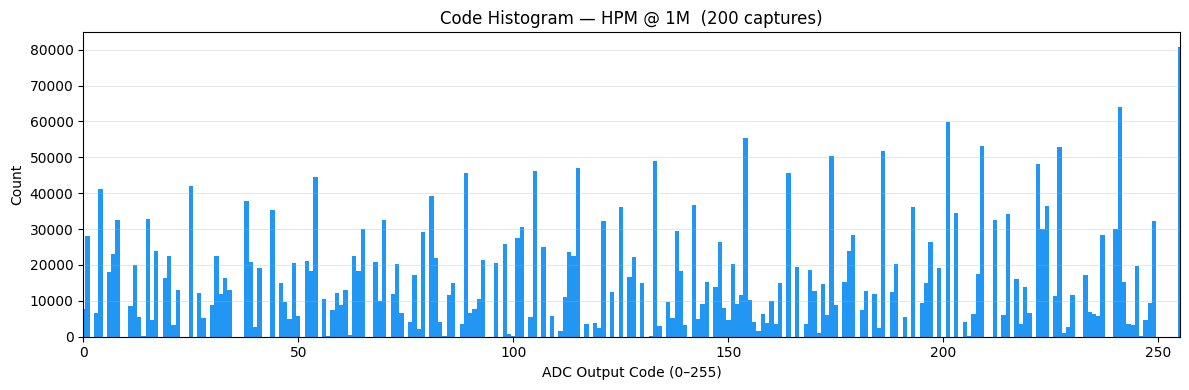

In [110]:
# ── Pick power mode and Fs to plot ───────────────────────────────────────────
pm_plot     = "HPM"
fs_plot     = "1M"

# ── Gather all codes across all captures for this pm/fs ──────────────────────
test_cols = [c for c in raw_dfs[pm_plot].columns if c.startswith(fs_plot)]
all_codes = np.concatenate([raw_dfs[pm_plot][col].dropna().values.astype(int)
                             for col in test_cols])

print(f"Total samples : {len(all_codes)}")
print(f"Unique codes  : {len(np.unique(all_codes))}")
print(f"Code range    : {all_codes.min()} – {all_codes.max()}")

# ── Histogram ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(np.arange(256),
       np.bincount(all_codes, minlength=256),
       width=1.0, color="#2196F3", edgecolor="none")

ax.set_title(f"Code Histogram — {pm_plot} @ {fs_plot}  ({len(test_cols)} captures)")
ax.set_xlabel("ADC Output Code (0–255)")
ax.set_ylabel("Count")
ax.set_xlim(0, 255)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Hm = 12551.95 counts (ideal bin height)
DNL max = +4.093 LSB,  min = -1.000 LSB
INL max = +6.162 LSB,  min = -5.539 LSB


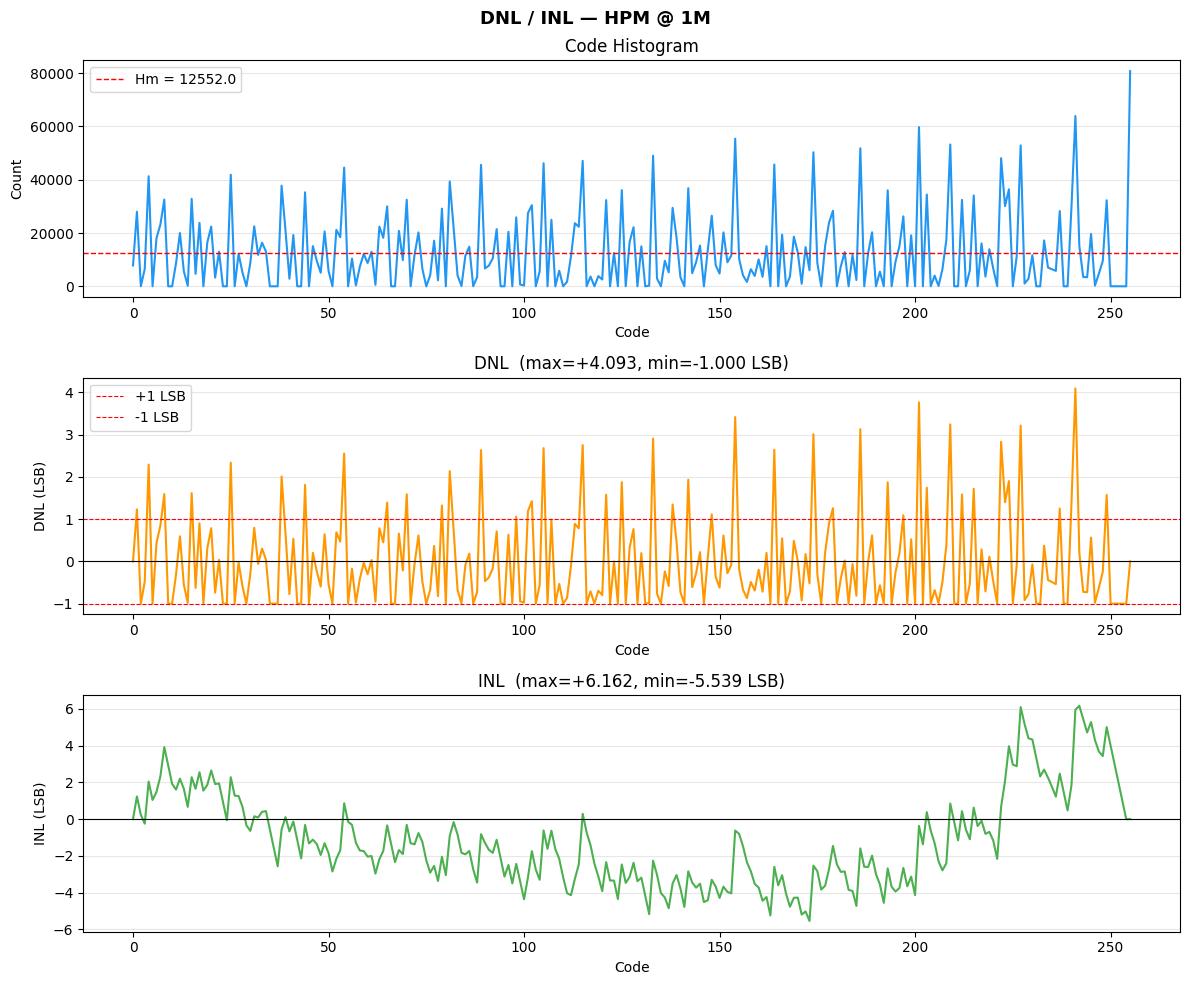

In [111]:
# ── Histogram H[i] ────────────────────────────────────────────────────────────
H = np.bincount(all_codes, minlength=256)   # H[0..255]

# ── Hm: average bin height from code 1 to 2^n - 2 (eq. 15) ──────────────────
n   = 8
Hm  = np.sum(H[1:2**n - 1]) / (2**n - 2)
print(f"Hm = {Hm:.2f} counts (ideal bin height)")

# ── DNL: eq. 16 ───────────────────────────────────────────────────────────────
DNL = np.zeros(256)
for i in range(1, 2**n - 1):
    DNL[i] = (H[i] / Hm) - 1.0
# endpoints defined as 0 per the paper
DNL[0]       = 0.0
DNL[2**n -1] = 0.0

# ── INL: eq. 17 — cumulative sum of DNL ──────────────────────────────────────
INL = np.zeros(256)
for i in range(1, 2**n - 1):
    INL[i] = np.sum(DNL[1:i+1])
INL[0]       = 0.0
INL[2**n -1] = 0.0

print(f"DNL max = +{DNL.max():.3f} LSB,  min = {DNL.min():.3f} LSB")
print(f"INL max = +{INL.max():.3f} LSB,  min = {INL.min():.3f} LSB")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle(f"DNL / INL — {pm_plot} @ {fs_plot}", fontsize=13, fontweight="bold")

# Histogram
axes[0].plot(np.arange(256), H, color="#2196F3")
axes[0].axhline(Hm, color="red", linestyle="--", linewidth=1, label=f"Hm = {Hm:.1f}")
axes[0].set_title("Code Histogram")
axes[0].set_xlabel("Code"); axes[0].set_ylabel("Count")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

# DNL
axes[1].plot(np.arange(256), DNL, color="#FF9800")
axes[1].axhline( 0, color="black", linewidth=0.8)
axes[1].axhline( 1, color="red",   linewidth=0.8, linestyle="--", label="+1 LSB")
axes[1].axhline(-1, color="red",   linewidth=0.8, linestyle="--", label="-1 LSB")
axes[1].set_title(f"DNL  (max=+{DNL.max():.3f}, min={DNL.min():.3f} LSB)")
axes[1].set_xlabel("Code"); axes[1].set_ylabel("DNL (LSB)")
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

# INL
axes[2].plot(np.arange(256), INL, color="#4CAF50")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title(f"INL  (max=+{INL.max():.3f}, min={INL.min():.3f} LSB)")
axes[2].set_xlabel("Code"); axes[2].set_ylabel("INL (LSB)")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [112]:
offset_error = INL[1]   # INL deviation at first code

# Fit a line to INL[1..254]
codes = np.arange(1, 255)
slope, intercept = np.polyfit(codes, INL[1:255], 1)
gain_error   = slope      # LSB/code
offset_error = intercept  # LSB

INL_corrected = np.zeros(256)
for i in range(1, 255):
    INL_corrected[i] = INL[i] - (slope * i + intercept)

# Recompute DNL from corrected INL
DNL_corrected = np.zeros(256)
DNL_corrected[1] = INL_corrected[1]
for i in range(2, 255):
    DNL_corrected[i] = INL_corrected[i] - INL_corrected[i-1]

print(f"Gain error   = {slope:.4f} LSB/code")
print(f"Offset error = {intercept:.4f} LSB")
print(f"Corrected INL max = +{INL_corrected.max():.3f}, min = {INL_corrected.min():.3f} LSB")
print(f"Corrected DNL max = +{DNL_corrected.max():.3f}, min = {DNL_corrected.min():.3f} LSB")

Gain error   = 0.0022 LSB/code
Offset error = -1.4489 LSB
Corrected INL max = +7.090, min = -4.462 LSB
Corrected DNL max = +4.091, min = -1.002 LSB


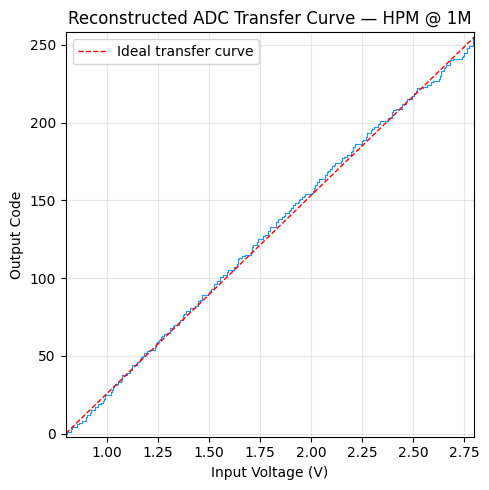

In [113]:


# ── Reconstructed Transfer Curve from DNL ─────────────────────────────────────
V_LO   = 0.8          # V
V_HI   = 2.8          # V
V_FS   = V_HI - V_LO  # 2.0 V full scale
V_LSB  = V_FS / 256   # ideal LSB width

# Step width of each transition: (1 + DNL[i]) * V_LSB
# DNL[0] = 0 by definition, so transition 0->1 is at V_LO + 1 ideal LSB
step_widths = (1.0 + DNL) * V_LSB   # shape (256,)

# Transition voltages: where each rising edge of the staircase occurs
# transition[i] = voltage at which output switches from i-1 to i
# transitions[1] = V_LO + step_widths[1], etc.
transitions = np.zeros(257)
transitions[0] = V_LO
for i in range(1, 257):
    transitions[i] = transitions[i-1] + step_widths[i-1]

# Build staircase: for each code i, horizontal segment from transitions[i] to transitions[i+1]
fig, ax = plt.subplots(figsize=(5, 5))

for code in range(256):
    x_left  = transitions[code]
    x_right = transitions[code + 1]
    # horizontal step
    ax.plot([x_left, x_right], [code, code], color="#2196F3", linewidth=0.8)
    # vertical riser (connect to next step), skip last
    if code < 255:
        ax.plot([x_right, x_right], [code, code + 1], color="#2196F3", linewidth=0.8)

# Ideal straight line (endpoints)
ax.plot([V_LO, V_HI], [0, 255], color="red", linestyle="--",
        linewidth=1.0, label="Ideal transfer curve")

ax.set_xlim(V_LO, V_HI)
ax.set_ylim(-2, 258)
ax.set_xlabel("Input Voltage (V)")
ax.set_ylabel("Output Code")
ax.set_title(f"Reconstructed ADC Transfer Curve — {pm_plot} @ {fs_plot}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

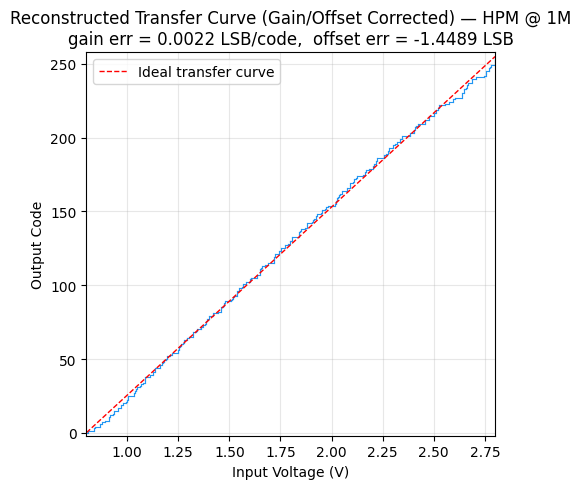

In [114]:
# ── Reconstructed Transfer Curve — Gain/Offset Corrected ──────────────────────
V_LO  = 0.8
V_HI  = 2.8
V_FS  = V_HI - V_LO
V_LSB = V_FS / 256

step_widths_corr = (1.0 + DNL_corrected) * V_LSB

transitions_corr = np.zeros(257)
transitions_corr[0] = V_LO
for i in range(1, 257):
    transitions_corr[i] = transitions_corr[i-1] + step_widths_corr[i-1]

fig, ax = plt.subplots(figsize=(5, 5))

for code in range(256):
    x_left  = transitions_corr[code]
    x_right = transitions_corr[code + 1]
    ax.plot([x_left, x_right], [code, code],   color="#2196F3", linewidth=0.8)
    if code < 255:
        ax.plot([x_right, x_right], [code, code + 1], color="#2196F3", linewidth=0.8)

ax.plot([V_LO, V_HI], [0, 255], color="red", linestyle="--",
        linewidth=1.0, label="Ideal transfer curve")

ax.set_xlim(V_LO, V_HI)
ax.set_ylim(-2, 258)
ax.set_xlabel("Input Voltage (V)")
ax.set_ylabel("Output Code")
ax.set_title(f"Reconstructed Transfer Curve (Gain/Offset Corrected) — {pm_plot} @ {fs_plot}\n"
             f"gain err = {slope:.4f} LSB/code,  offset err = {intercept:.4f} LSB")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [115]:
# After you've computed H (bincount from ramp data)
counts = H  # you already have this

threshold = len(all_codes) * 0.001
active_codes = np.where(counts >= threshold)[0]
N_active = len(active_codes)

V_FS = 2.0  # your 2V full-scale range (REF_HI - REF_LO)
lut_voltage = np.zeros(256)

for rank, code in enumerate(active_codes):
    lut_voltage[code] = rank * (V_FS / (N_active - 1))

# Snap missing codes to nearest active
for code in range(256):
    if counts[code] < threshold:
        nearest = active_codes[np.argmin(np.abs(active_codes - code))]
        lut_voltage[code] = lut_voltage[nearest]

# Save
lut_df = pd.DataFrame({
    "raw_code":           np.arange(256),
    "calibrated_voltage": lut_voltage,
    "is_active":          (counts >= threshold)
})
lut_df.to_csv("/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/adc_lut.csv", index=False)
print(f"LUT saved — {N_active} active codes, effective LSB = {V_FS/(N_active-1)*1000:.4f} mV")

LUT saved — 167 active codes, effective LSB = 12.0482 mV


In [122]:
H_df = pd.DataFrame(H)
H_df.head()
H_df.to_csv('histogram_data')

── Uncalibrated ──────────────────────────────
DNL: +4.093 / -1.000 LSB
INL: +6.162 / -5.539 LSB

── Missing-code filled ───────────────────────
DNL: +2.589 / -1.000 LSB
INL: +8.029 / -11.573 LSB


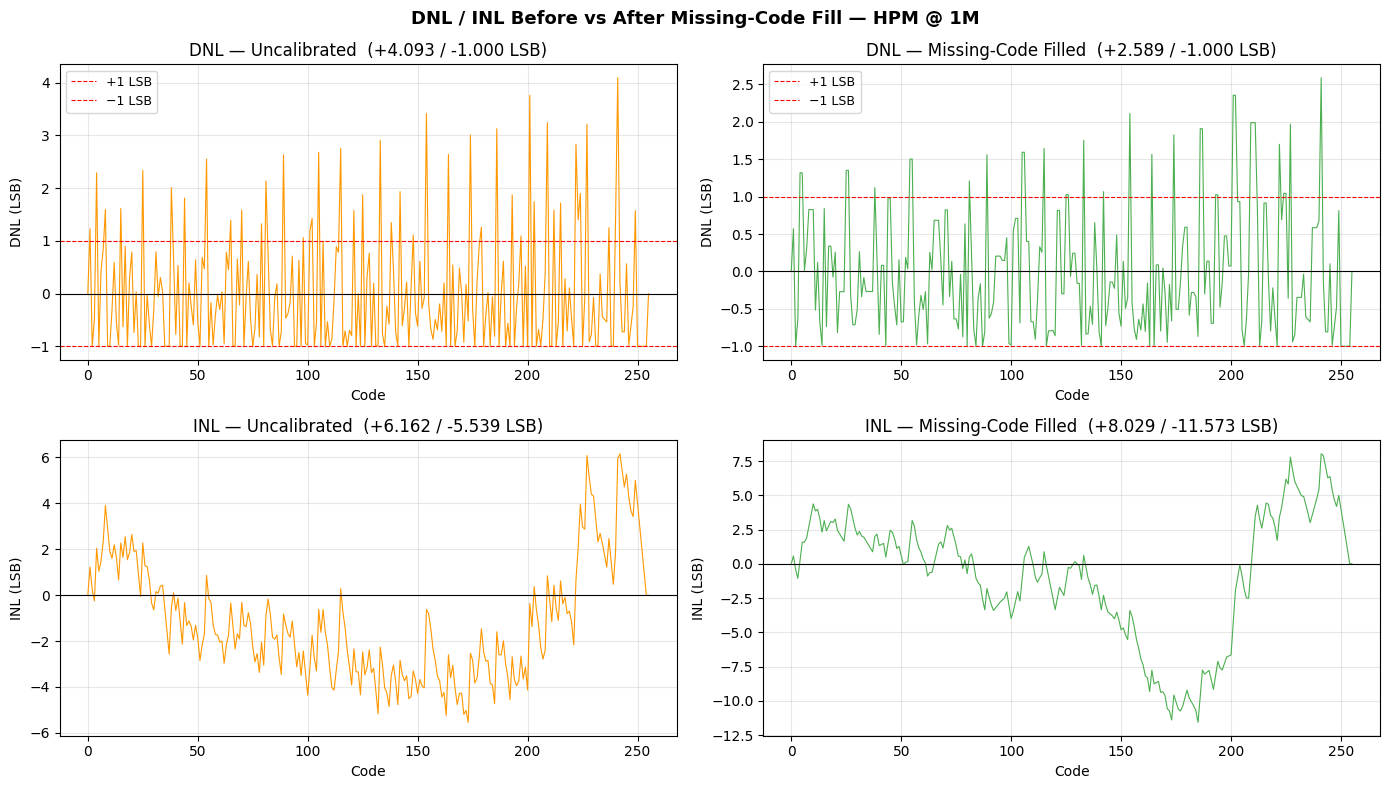

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Fill missing codes (zero bins) with nearest neighbor count
# ══════════════════════════════════════════════════════════════════════════════
H_filled = H.copy().astype(float)

# for code in range(256):
#     if H_filled[code] == 0:
#         # Find nearest non-zero neighbor
#         distances = np.abs(np.arange(256) - code)
#         distances[H_filled == 0] = 999999  # exclude other zeros
#         nearest = np.argmin(distances)
#         H_filled[code] = H_filled[nearest]

H_filled = H.copy().astype(float)

for code in range(256):
    if H_filled[code] == 0:
        distances = np.abs(np.arange(256) - code)
        distances[H_filled == 0] = 999999
        nearest = np.argmin(distances)
        # Split the neighbor's count between the two codes
        H_filled[code]    = H_filled[nearest] / 2.0
        H_filled[nearest] = H_filled[nearest] / 2.0

# ══════════════════════════════════════════════════════════════════════════════
# Recompute DNL / INL on filled histogram (same method as uncalibrated)
# ══════════════════════════════════════════════════════════════════════════════
n     = 8
Hm_f  = np.sum(H_filled[1:2**n - 1]) / (2**n - 2)

DNL_f = np.zeros(256)
for i in range(1, 2**n - 1):
    DNL_f[i] = (H_filled[i] / Hm_f) - 1.0
DNL_f[0]       = 0.0
DNL_f[2**n -1] = 0.0

INL_f = np.zeros(256)
for i in range(1, 2**n - 1):
    INL_f[i] = np.sum(DNL_f[1:i + 1])
INL_f[0]       = 0.0
INL_f[2**n -1] = 0.0

print(f"── Uncalibrated ──────────────────────────────")
print(f"DNL: +{DNL.max():.3f} / {DNL.min():.3f} LSB")
print(f"INL: +{INL.max():.3f} / {INL.min():.3f} LSB")
print(f"\n── Missing-code filled ───────────────────────")
print(f"DNL: +{DNL_f.max():.3f} / {DNL_f.min():.3f} LSB")
print(f"INL: +{INL_f.max():.3f} / {INL_f.min():.3f} LSB")

# ══════════════════════════════════════════════════════════════════════════════
# Plot: before vs after
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"DNL / INL Before vs After Missing-Code Fill — {pm_plot} @ {fs_plot}",
             fontsize=13, fontweight="bold")

codes_axis = np.arange(256)

axes[0, 0].plot(codes_axis, DNL, color="#FF9800", linewidth=0.8)
axes[0, 0].axhline( 0, color="black", linewidth=0.8)
axes[0, 0].axhline( 1, color="red", linewidth=0.8, linestyle="--", label="+1 LSB")
axes[0, 0].axhline(-1, color="red", linewidth=0.8, linestyle="--", label="−1 LSB")
axes[0, 0].set_title(f"DNL — Uncalibrated  (+{DNL.max():.3f} / {DNL.min():.3f} LSB)")
axes[0, 0].set_ylabel("DNL (LSB)"); axes[0, 0].set_xlabel("Code")
axes[0, 0].legend(fontsize=9); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(codes_axis, DNL_f, color="#4CAF50", linewidth=0.8)
axes[0, 1].axhline( 0, color="black", linewidth=0.8)
axes[0, 1].axhline( 1, color="red", linewidth=0.8, linestyle="--", label="+1 LSB")
axes[0, 1].axhline(-1, color="red", linewidth=0.8, linestyle="--", label="−1 LSB")
axes[0, 1].set_title(f"DNL — Missing-Code Filled  (+{DNL_f.max():.3f} / {DNL_f.min():.3f} LSB)")
axes[0, 1].set_ylabel("DNL (LSB)"); axes[0, 1].set_xlabel("Code")
axes[0, 1].legend(fontsize=9); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(codes_axis, INL, color="#FF9800", linewidth=0.8)
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set_title(f"INL — Uncalibrated  (+{INL.max():.3f} / {INL.min():.3f} LSB)")
axes[1, 0].set_ylabel("INL (LSB)"); axes[1, 0].set_xlabel("Code")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(codes_axis, INL_f, color="#4CAF50", linewidth=0.8)
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_title(f"INL — Missing-Code Filled  (+{INL_f.max():.3f} / {INL_f.min():.3f} LSB)")
axes[1, 1].set_ylabel("INL (LSB)"); axes[1, 1].set_xlabel("Code")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()